### Importy i ścieżki

In [ ]:
import json
import ast
import re
import pandas as pd
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt
import numpy as np
import statsmodels.api as sm
from scipy.stats import norm
from scipy.stats import shapiro
from scipy.stats import ks_2samp, chi2_contingency

import pandas as pd
from scipy.stats import ks_2samp, chi2_contingency


from src.data.create_dataset import create_final_dataset

In [10]:
path = "../microservice/AB_experiments/logs/app.log"

### Funckja do wczytywania logów do jsona

In [103]:
def parse_log_line(line):
    pattern = re.compile(
        r"^(?P<timestamp>[\d\-\s:,]+) - INFO - client=[^ ]+ model=(?P<model>\w+) listing_id=(?P<listing_id>\d+) prediction=(?P<prediction>\w+) input=(?P<input>\{.*\})"
    )
    m = pattern.match(line)
    if not m:
        return None
    data = m.groupdict()
    try:
        data['input'] = ast.literal_eval(data['input'])
    except Exception as e:
        json_str = data['input'].replace("'", '"')
        data['input'] = json.loads(json_str)
    return data

In [105]:
parsed = []
with open(path, 'r') as f:
    for line in f:
        entry = parse_log_line(line.strip())
        if entry:
            parsed.append(entry)


logs = pd.json_normalize(parsed)
logs['timestamp'] = pd.to_datetime(logs['timestamp'], format='%Y-%m-%d %H:%M:%S,%f')

In [106]:
logs.head()

,timestamp,model,listing_id,prediction,input.id,input.host_acceptance_rate,input.latitude,input.longitude,input.accommodates,input.bathrooms,input.bedrooms,input.beds,input.price,input.review_scores_rating,input.review_scores_accuracy,input.review_scores_cleanliness,input.review_scores_checkin,input.review_scores_communication,input.review_scores_location,input.review_scores_value,input.reviews_per_month,input.total_bookings,input.total_reviews,input.total_english_reviews,input.count_negative_english,input.count_positive_english,input.amenities,input.host_is_superhost,input.host_verifications,input.property_type,input.room_type,input.bathrooms_text,input.instant_bookable
0,2025-06-08 18:36:41.759,base,27262,short,27262,100.0,37.98924,23.76500,2,1.0,1.0,1.0,131.0,4.86,4.89,4.90,4.86,4.97,4.75,4.71,0.19,29,29,17,0,17,"[""Heating - split type ductless system"", ""Dish...",True,"['email', 'phone']",Entire rental unit,Entire home/apt,1 bath,t
1,2025-06-08 18:36:41.771,base,809874,short,809874,96.0,37.96215,23.72179,4,1.0,1.0,2.0,108.0,4.96,4.97,4.97,4.89,4.92,4.86,4.91,0.68,97,97,82,0,82,"[""Host greets you"", ""Dishes and silverware"", ""...",False,"['email', 'phone']",Entire rental unit,Entire home/apt,1 bath,f
2,2025-06-08 18:36:41.782,base,866381,short,866381,97.0,37.95523,23.72443,3,1.0,1.0,1.0,85.0,4.95,4.98,4.98,4.93,4.93,4.73,4.90,0.28,40,40,31,0,31,"[""Coffee"", ""Dishes and silverware"", ""Washer"", ...",True,"['email', 'phone', 'work_email']",Entire condo,Entire home/apt,1 bath,f
3,2025-06-08 18:36:41.792,base,886724,short,886724,0.0,37.99745,23.73973,2,1.0,1.0,1.0,56.0,4.61,4.88,4.47,4.88,4.89,4.28,4.72,0.14,18,18,17,1,16,"[""Host greets you"", ""Luggage dropoff allowed"",...",False,['email'],Entire rental unit,Entire home/apt,1 bath,f
4,2025-06-08 18:36:41.810,xgboost,896212,long,896212,100.0,37.98844,23.73845,2,1.0,1.0,1.0,63.0,4.95,4.94,4.96,4.97,4.93,4.82,4.93,3.58,515,515,423,3,420,"[""Host greets you"", ""Coffee"", ""Dishes and silv...",True,"['email', 'phone']",Entire rental unit,Entire home/apt,1 bath,t


In [107]:
logs.tail()

,timestamp,model,listing_id,prediction,input.id,input.host_acceptance_rate,input.latitude,input.longitude,input.accommodates,input.bathrooms,input.bedrooms,input.beds,input.price,input.review_scores_rating,input.review_scores_accuracy,input.review_scores_cleanliness,input.review_scores_checkin,input.review_scores_communication,input.review_scores_location,input.review_scores_value,input.reviews_per_month,input.total_bookings,input.total_reviews,input.total_english_reviews,input.count_negative_english,input.count_positive_english,input.amenities,input.host_is_superhost,input.host_verifications,input.property_type,input.room_type,input.bathrooms_text,input.instant_bookable
22451,2025-06-08 18:43:04.255,xgboost,1365635357360238848,short,1365635357360238932,47.0,40.423077,-3.654061,3,1.0,1.0,2.0,57.0,5.00,5.00,5.0,5.00,5.00,5.00,5.00,1.00,1,1,0,0,0,"[""Smoking allowed"", ""Air conditioning"", ""Wifi""...",False,"['email', 'phone']",Private room in rental unit,Private room,1 shared bath,f
22452,2025-06-08 18:43:04.336,xgboost,1366534590465861888,short,1366534590465861868,67.0,40.461157,-3.698250,1,3.0,1.0,1.0,19.0,5.00,5.00,4.0,5.00,5.00,5.00,5.00,1.00,1,1,1,0,1,"[""Paid parking on premises"", ""Self check-in"", ...",False,"['email', 'phone']",Shared room in hotel,Shared room,3 shared baths,t
22453,2025-06-08 18:43:04.350,base,1368304377290123264,short,1368304377290123314,100.0,40.434096,-3.609342,2,1.0,1.0,1.0,53.0,5.00,5.00,5.0,5.00,5.00,5.00,5.00,1.00,1,1,0,0,0,"[""Cleaning available during stay"", ""Wifi"", ""Wi...",False,['phone'],Private room in rental unit,Private room,1 private bath,f
22454,2025-06-08 18:43:58.268,xgboost,27262,short,27262,100.0,37.989240,23.765000,2,1.0,1.0,1.0,131.0,4.86,4.89,4.9,4.86,4.97,4.75,4.71,0.19,29,29,17,0,17,Wifi,True,Email,Earthen home,Entire home/apt,1.5 baths,f
22455,2025-06-08 18:43:58.280,base,27262,short,27262,100.0,37.989240,23.765000,2,1.0,1.0,1.0,131.0,4.86,4.89,4.9,4.86,4.97,4.75,4.71,0.19,29,29,17,0,17,Wifi,True,Email,Earthen home,Entire home/apt,1.5 baths,f


### Wczytanie danych w celu sprawdzenia, czy predykcje są dobrze wykonywane

In [108]:
final_df = create_final_dataset()[['id', 'target']]
final_df.head()

,id,target
0,27262,short
1,809874,short
2,866381,long
3,886724,short
4,896212,long


### Porównanie błędów modeli

In [ ]:
models_preds = logs[['listing_id', 'model', 'prediction', 'timestamp']]
models_preds.head()

,listing_id,model,prediction,timestamp
0,27262,base,short,2025-06-08 18:36:41.759
1,809874,base,short,2025-06-08 18:36:41.771
2,866381,base,short,2025-06-08 18:36:41.782
3,886724,base,short,2025-06-08 18:36:41.792
4,896212,xgboost,long,2025-06-08 18:36:41.810


In [110]:
models_preds['listing_id'] = models_preds['listing_id'].astype(int)

merged_df = pd.merge(models_preds, final_df, left_on='listing_id', right_on='id', how='left')
merged_df.drop(columns=['id'], inplace=True)
merged_df.head()

/tmp/ipykernel_1107/2705393533.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  models_preds['listing_id'] = models_preds['listing_id'].astype(int)


,listing_id,model,prediction,timestamp,target
0,27262,base,short,2025-06-08 18:36:41.759,short
1,809874,base,short,2025-06-08 18:36:41.771,short
2,866381,base,short,2025-06-08 18:36:41.782,long
3,886724,base,short,2025-06-08 18:36:41.792,short
4,896212,xgboost,long,2025-06-08 18:36:41.810,long


In [113]:
# how many each model predicted
model_counts = merged_df['model'].dropna().value_counts()
print(model_counts)

model
xgboost    11296
base       11160
Name: count, dtype: int64


In [114]:
#mistakes by each model
mistake_counts_by_target = merged_df[merged_df['prediction'] != merged_df['target']].groupby(['model', 'target']).size().unstack(fill_value=0)
print(mistake_counts_by_target)

target   long  short
model               
base     1173      0
xgboost   351      8


In [115]:
# total model mistakes
mistakes = merged_df.loc[merged_df['target'].notnull() & (merged_df['prediction'] != merged_df['target'])]
total_mistakes = mistakes.groupby('model').size()
print(total_mistakes)

model
base       1173
xgboost     359
dtype: int64


# Macierz pomyłek oraz wartości metryk

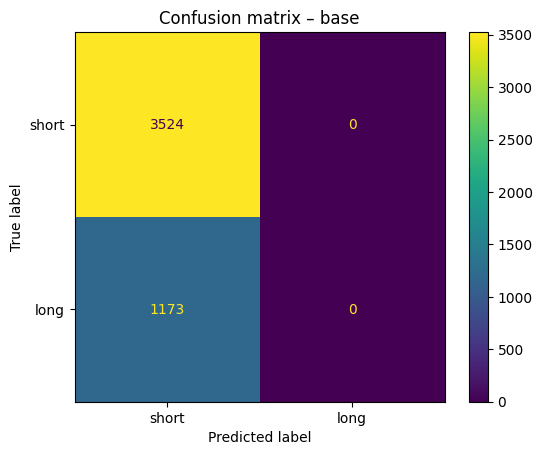


Classification report for base:
              precision    recall  f1-score   support

       short       0.75      1.00      0.86      3524
        long       0.00      0.00      0.00      1173

    accuracy                           0.75      4697
   macro avg       0.38      0.50      0.43      4697
weighted avg       0.56      0.75      0.64      4697



/root/.cache/pypoetry/virtualenvs/ium-long-stay-insights-DB1IbSqe-py3.12/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/root/.cache/pypoetry/virtualenvs/ium-long-stay-insights-DB1IbSqe-py3.12/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/root/.cache/pypoetry/virtualenvs/ium-long-stay-insights-DB1IbSqe-py3.12/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted s

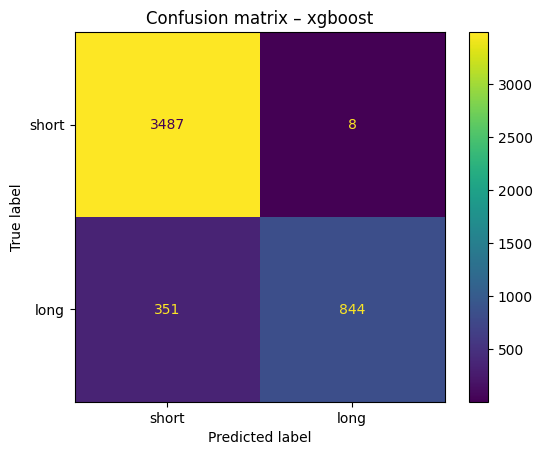


Classification report for xgboost:
              precision    recall  f1-score   support

       short       0.91      1.00      0.95      3495
        long       0.99      0.71      0.82      1195

    accuracy                           0.92      4690
   macro avg       0.95      0.85      0.89      4690
weighted avg       0.93      0.92      0.92      4690



In [116]:

clean = merged_df.dropna(subset=['prediction', 'target']).copy()

clean['prediction'] = clean['prediction'].astype(str)
clean['target']     = clean['target'].astype(str)

labels = ['short', 'long']

def plot_confusion_for_model(df, model_name):
    sub = df[df['model'] == model_name]
    y_true = sub['target']
    y_pred = sub['prediction']
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    disp = ConfusionMatrixDisplay(cm, display_labels=labels)
    fig, ax = plt.subplots()
    disp.plot(ax=ax)
    ax.set_title(f'Confusion matrix – {model_name}')
    plt.show()
    print(f"\nClassification report for {model_name}:")
    print(classification_report(y_true, y_pred, labels=labels))

for model in clean['model'].unique():
    plot_confusion_for_model(clean, model)


# Weryfikacja testu AB

In [117]:
def z_test_values(df, model):
    n = len(df[(df['model'] == model) & (df['target'].notnull())])
    k = len(df[(df['model'] == model) & (df['target'] == df['prediction']) & (df['target'].notnull())])
    p = k / n if n else None
    return n, k, p

xgb_n, xgb_k, xgb_p = z_test_values(clean, 'xgboost')
n, k, p = z_test_values(clean, 'base')


In [118]:
print(f"XGBoost: n={xgb_n}, k={xgb_k}, p={xgb_p}")
print(f"Base: n={n}, k={k}, p={p}")

XGBoost: n=4690, k=4331, p=0.9234541577825159
Base: n=4697, k=3524, p=0.7502661273153076


In [119]:
total_p = (xgb_k + k)/ (xgb_n + n)

z_score = (xgb_p - p) / ((xgb_p * (1 - xgb_p) / xgb_n) + (p * (1 - p) / n)) ** 0.5
print(f"Total p: {total_p}")
print(f"Z-score: {z_score}")


alpha = 0.05
z_critical = norm.ppf(1 - alpha / 2)
print(f"Z-critical value for alpha={alpha}: {z_critical}")

Total p: 0.8367955683391926
Z-score: 23.36063078162514
Z-critical value for alpha=0.05: 1.959963984540054


### Równoważenie grup i balans cech

In [ ]:
# 1) Przygotowanie danych
df = df.copy()  # Twój DataFrame
# liczba amenities i weryfikacji
df['n_amenities']       = df['input.amenities'].apply(len)
df['n_verifications']   = df['input.host_verifications'].apply(len)
# host_is_superhost → int
df['is_superhost']      = df['input.host_is_superhost'].astype(int)

# zdefiniuj zmienne
cont_feats = [
    'input.host_acceptance_rate', 'input.latitude', 'input.longitude',
    'input.accommodates', 'input.bathrooms', 'input.bedrooms', 'input.beds',
    'input.price', 'input.review_scores_rating',
    'input.reviews_per_month', 'input.total_bookings',
    'n_amenities', 'n_verifications'
]
cat_feats = [
    'input.property_type', 'input.room_type', 'input.bathrooms_text',
    'input.instant_bookable', 'is_superhost'
]

# 2) Funkcja testująca balans
def balance_tests(df, group_col, cont_features, cat_features, group_a, group_b, alpha=0.05):
    df_a = df[df[group_col] == group_a]
    df_b = df[df[group_col] == group_b]
    results = []

    # KS-test dla cech ciągłych
    for feat in cont_features:
        xa = df_a[feat].dropna()
        xb = df_b[feat].dropna()
        stat, p = ks_2samp(xa, xb)
        results.append({
            'feature':   feat,
            'test':      'KS',
            'statistic': stat,
            'p_value':   p,
            'balanced':  p >= alpha
        })

    # Chi-kwadrat dla kategorycznych
    for feat in cat_features:
        # crosstab: wiersze = kategorie, kolumny = grupa
        ct = pd.crosstab(df[group_col], df[feat])
        chi2, p, _, _ = chi2_contingency(ct, correction=False)
        results.append({
            'feature':   feat,
            'test':      'chi2',
            'statistic': chi2,
            'p_value':   p,
            'balanced':  p >= alpha
        })

    return pd.DataFrame(results)

# 3) Uruchomienie testów
balance_df = balance_tests(
    df=  df,
    group_col=    'model',
    cont_features=cont_feats,
    cat_features= cat_feats,
    group_a=      'base',
    group_b=      'xgboost',
    alpha=        0.05
)

print(balance_df)


                       feature  test  statistic   p_value  balanced
0   input.host_acceptance_rate    KS   0.011258  0.471798      True
1               input.latitude    KS   0.018878  0.036122     False
2              input.longitude    KS   0.013277  0.273205      True
3           input.accommodates    KS   0.009414  0.698577      True
4              input.bathrooms    KS   0.003686  0.999999      True
5               input.bedrooms    KS   0.008873  0.765232      True
6                   input.beds    KS   0.014639  0.178459      True
7                  input.price    KS   0.008320  0.828666      True
8   input.review_scores_rating    KS   0.019553  0.026977     False
9      input.reviews_per_month    KS   0.011052  0.495742      True
10        input.total_bookings    KS   0.008201  0.841441      True
11                 n_amenities    KS   0.009602  0.674968      True
12             n_verifications    KS   0.006481  0.971230      True
13         input.property_type  chi2  48.663042 

In [92]:
df['price_bucket'] = pd.qcut(df['input.price'], 10)
pivot = df.pivot_table(index='price_bucket', columns='prediction',
                       values='listing_id', aggfunc='count').apply(lambda x: x/x.sum(), axis=1)
print(pivot)

prediction            long     short
price_bucket                        
(9.999, 37.0]     0.018884  0.981116
(37.0, 49.0]      0.180784  0.819216
(49.0, 60.0]      0.222590  0.777410
(60.0, 71.0]      0.235265  0.764735
(71.0, 83.0]      0.244056  0.755944
(83.0, 97.0]      0.090127  0.909873
(97.0, 115.0]     0.000000  1.000000
(115.0, 140.0]    0.000000  1.000000
(140.0, 188.0]    0.000000  1.000000
(188.0, 19276.0]  0.000000  1.000000


/tmp/ipykernel_1107/640696745.py:2: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = df.pivot_table(index='price_bucket', columns='prediction',


In [94]:
import pandas as pd

# 1) Utwórz bucket cenowy
df['price_bucket'] = pd.qcut(df['input.price'], 10)

# 2) Pivot‐table z normalizacją w każdym modelu osobno
pt = df.pivot_table(
    index='price_bucket',
    columns=['model','prediction'],
    values='listing_id',
    aggfunc='count',
    fill_value=0
)

# 3) Zamień na odsetki w każdej grupie model-bucket
pt_pct = pt.div(pt.sum(axis=1), axis=0)

# 4) Wydrukuj tylko kolumny 'long'
print(pt_pct.xs('long', axis=1, level='prediction'))

# 4) Wydrukuj tylko kolumny 'long'
print(pt_pct.xs('short', axis=1, level='prediction'))


model             base   xgboost
price_bucket                    
(9.999, 37.0]      0.0  0.018884
(37.0, 49.0]       0.0  0.180784
(49.0, 60.0]       0.0  0.222590
(60.0, 71.0]       0.0  0.235265
(71.0, 83.0]       0.0  0.244056
(83.0, 97.0]       0.0  0.090127
(97.0, 115.0]      0.0  0.000000
(115.0, 140.0]     0.0  0.000000
(140.0, 188.0]     0.0  0.000000
(188.0, 19276.0]   0.0  0.000000
model                 base   xgboost
price_bucket                        
(9.999, 37.0]     0.491436  0.489679
(37.0, 49.0]      0.504846  0.314370
(49.0, 60.0]      0.502689  0.274721
(60.0, 71.0]      0.503653  0.261081
(71.0, 83.0]      0.474652  0.281292
(83.0, 97.0]      0.517210  0.392663
(97.0, 115.0]     0.492417  0.507583
(115.0, 140.0]    0.494918  0.505082
(140.0, 188.0]    0.512320  0.487680
(188.0, 19276.0]  0.476148  0.523852


/tmp/ipykernel_1107/2587196335.py:7: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pt = df.pivot_table(


In [96]:
# 1) Zliczenia per model, bucket i prediction
counts = df.groupby(['model','price_bucket','prediction']) \
           .size() \
           .unstack(fill_value=0)

# 2) Normalizacja wewnątrz każdego modelu+bucket
props = counts.div(counts.sum(axis=1), axis=0)

# 3) Rozdzielenie na long vs short
long_props  = props.xs('long',  axis=1)
short_props = props.xs('short', axis=1)

print("Udział predykcji LONG w każdym modelu i przedziale cenowym:")
print(long_props)

print("\nUdział predykcji SHORT w każdym modelu i przedziale cenowym:")
print(short_props)


Udział predykcji LONG w każdym modelu i przedziale cenowym:
model    price_bucket    
base     (9.999, 37.0]       0.000000
         (37.0, 49.0]        0.000000
         (49.0, 60.0]        0.000000
         (60.0, 71.0]        0.000000
         (71.0, 83.0]        0.000000
         (83.0, 97.0]        0.000000
         (97.0, 115.0]       0.000000
         (115.0, 140.0]      0.000000
         (140.0, 188.0]      0.000000
         (188.0, 19276.0]    0.000000
xgboost  (9.999, 37.0]       0.037133
         (37.0, 49.0]        0.365106
         (49.0, 60.0]        0.447587
         (60.0, 71.0]        0.473994
         (71.0, 83.0]        0.464560
         (83.0, 97.0]        0.186679
         (97.0, 115.0]       0.000000
         (115.0, 140.0]      0.000000
         (140.0, 188.0]      0.000000
         (188.0, 19276.0]    0.000000
Name: long, dtype: float64

Udział predykcji SHORT w każdym modelu i przedziale cenowym:
model    price_bucket    
base     (9.999, 37.0]       1.000000
 

/tmp/ipykernel_1107/1804569011.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts = df.groupby(['model','price_bucket','prediction']) \


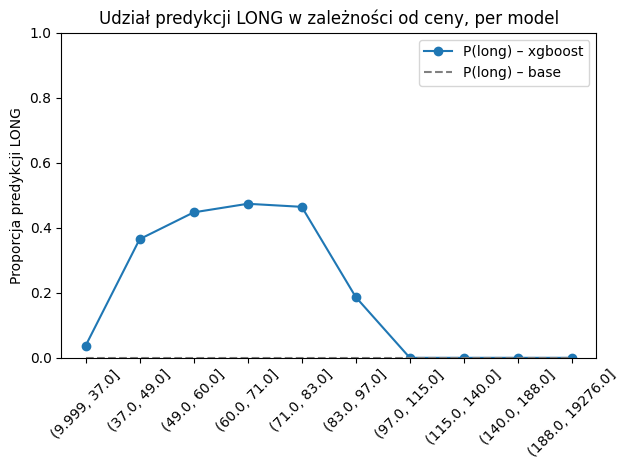

In [ ]:

# Weź tylko xgboost (base i tak zawsze 0/100%)
pt = long_props.loc['xgboost']

plt.plot(pt.index.astype(str), pt.values, marker='o', label='P(long) – xgboost')
plt.hlines(0, 0, len(pt)-1, colors='gray', linestyles='--', label='P(long) – base')

plt.xticks(rotation=45)
plt.ylim(0, 1)
plt.ylabel("Proporcja predykcji LONG")
plt.title("Udział predykcji LONG w zależności od ceny, per model")
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:


# Załóżmy, że masz DataFrame df z kolumnami:
#   - 'model' ∈ {'base','xgboost'}
#   - 'prediction'
#   - 'ground_truth'

# 1) Zakoduj błąd jako 0/1
df = merged_df.copy()  # Twój DataFrame
df = df.dropna(subset=['prediction', 'target'])

df['is_error'] = (df['prediction'] != df['target']).astype(int)

# 2) Nadaj każdej obserwacji numer w ramach swojego modelu i oblicz batch = index // 200
df['seq_in_model'] = df.groupby('model').cumcount()
df['batch'] = df['seq_in_model'] // 200   # batch 0 = pierwsze 200, 1 = kolejne 200 itd.

# 3) Podsumowanie per model/batch
summary = (
    df
    .groupby(['model','batch'])
    .agg(
        total=('is_error','size'),
        errors=('is_error','sum')
    )
    .reset_index()
)
summary['error_rate'] = summary['errors'] / summary['total']

print("Liczba i odsetek błędów w każdej paczce (batch) dla obu modeli:")
print(summary)

# 4) Testy normalności rozkładu error_rate
print("\nTest Shapiro–Wilka dla odsetków błędów w paczkach:")
for model_name, grp in summary.groupby('model'):
    stat, p_value = shapiro(grp['error_rate'])
    print(f"  {model_name}: W={stat:.3f}, p-value={p_value:.3f}")
    if p_value < 0.05:
        print("    → rozkład odsetków błędów **nie** jest normalny")
    else:
        print("    → rozkład odsetków błędów jest zgodny z normalnym")


Liczba i odsetek błędów w każdej paczce (batch) dla obu modeli:
      model  batch  total  errors  error_rate
0      base      0    200      79    0.395000
1      base      1    200      79    0.395000
2      base      2    200      79    0.395000
3      base      3    200      79    0.395000
4      base      4    200      77    0.385000
5      base      5    200      72    0.360000
6      base      6    200      68    0.340000
7      base      7    200      77    0.385000
8      base      8    200      80    0.400000
9      base      9    200      69    0.345000
10     base     10    200      64    0.320000
11     base     11    200      40    0.200000
12     base     12    200      44    0.220000
13     base     13    200      28    0.140000
14     base     14    200      30    0.150000
15     base     15    200      23    0.115000
16     base     16    200      25    0.125000
17     base     17    200      35    0.175000
18     base     18    200      25    0.125000
19     base     

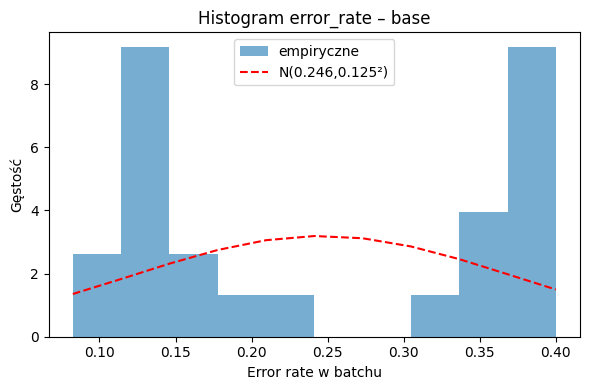

<Figure size 600x400 with 0 Axes>

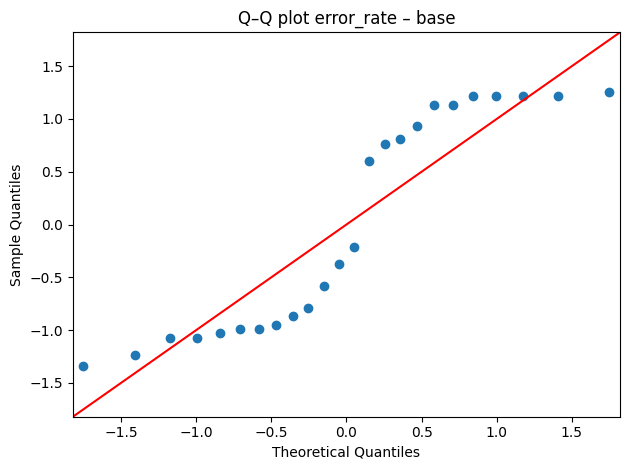

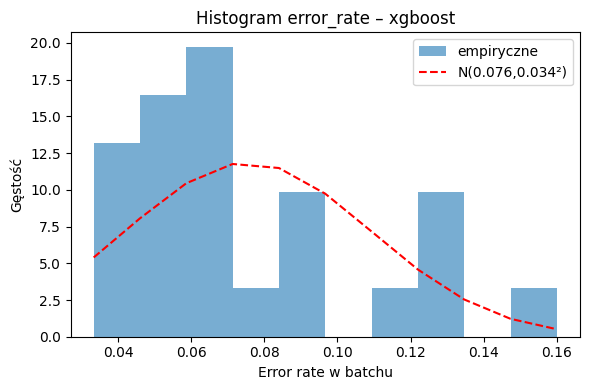

<Figure size 600x400 with 0 Axes>

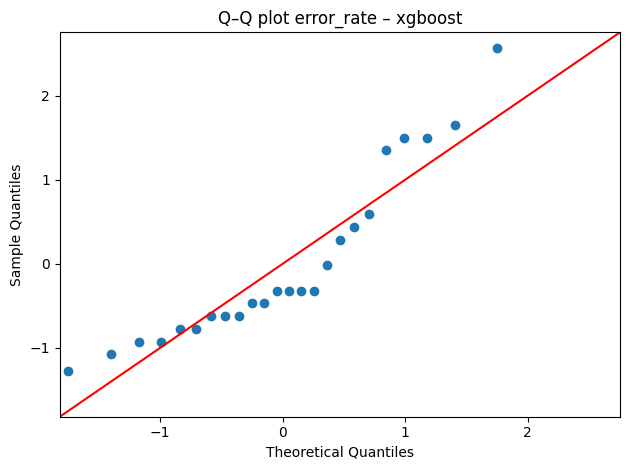

In [ ]:


# Zakładamy, że 'summary' to DataFrame z kolumnami ['model','batch','error_rate']
for model_name, grp in summary.groupby('model'):
    data = grp['error_rate'].values
    mu, sigma = data.mean(), data.std(ddof=1)

    # 1) Histogram + nakładka normalna
    plt.figure(figsize=(6,4))
    count, bins, _ = plt.hist(data, bins=10, density=True, alpha=0.6, label='empiryczne')
    plt.plot(bins, norm.pdf(bins, mu, sigma), 'r--',
             label=f'N({mu:.3f},{sigma:.3f}²)')
    plt.title(f"Histogram error_rate – {model_name}")
    plt.xlabel("Error rate w batchu")
    plt.ylabel("Gęstość")
    plt.legend()
    plt.tight_layout()

    # 2) Q–Q plot
    plt.figure(figsize=(6,4))
    sm.qqplot(data, line='45', fit=True)
    plt.title(f"Q–Q plot error_rate – {model_name}")
    plt.tight_layout()

plt.show()
